Importing the libraries

In [24]:

import numpy as np
import matplotlib.pyplot as plt


creating XOR table using arrays


In [25]:
# Input values
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
#output values
y = np.array([[0],
              [1],
              [1],
              [0]])

Initializing weights (Importance)

In [26]:
np.random.seed(42)
W1 = np.random.randn(2,4)
b1 = np.zeros((1,4))
W2 = np.random.randn(4,1)
b2 = np.zeros((1,1))

using activation functions (ReLU or Sigmoid)

In [27]:
def sigmoid(z):
    return 1 /(1+np.exp(-z))
def sigmoid_derivative(a):
    return a*(1-a)
def relu(z):
    return np.maximum(0,z)
def relu_derivative(z):
    return (z> 0).astype(float)

training loop with loss computation

In [28]:
learning_rate= 0.1
epochs= 5000
losses= []
for epoch in range(epochs):
    #Forward Propagation
    Z1= np.dot(X,W1)+b1
    A1= relu(Z1)
    Z2= np.dot(A1,W2)+b2
    A2= sigmoid(Z2)
    #Loss computaion
    loss= np.mean((A2-y)**2)
    losses.append(loss)
    #Backward Propagation
    dZ2= A2-y
    dW2= np.dot(A1.T,dZ2)
    db2= np.sum(dZ2,axis=0,keepdims=True)
    dA1= np.dot(dZ2,W2.T)
    dZ1= dA1*relu_derivative(Z1)
    dW1= np.dot(X.T,dZ1)
    db1= np.sum(dZ1,axis=0,keepdims=True)
    #Updating Weights
    W2-= learning_rate*dW2
    b2-= learning_rate*db2
    W1-= learning_rate*dW1
    b1-= learning_rate*db1

display of loss reduction over epochs

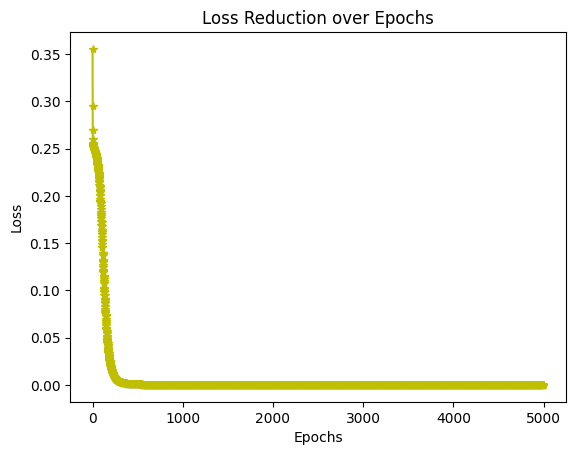

In [29]:
plt.plot(losses,color ="y",marker ="*")
plt.title("Loss Reduction over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

 final classification accuracy

In [30]:
Z1= np.dot(X,W1)+b1
A1= relu(Z1)
Z2= np.dot(A1,W2)+b2
A2= sigmoid(Z2)
prediction= (A2>0.5)
accuracy=np.mean(prediction==y)
print("Final Accuracy:",accuracy)

Final Accuracy: 1.0
